# Определение стоимости автомобилей

Сервис по продаже автомобилей с пробегом «Не бит, не крашен» разрабатывает приложение для привлечения новых клиентов. В нём можно быстро узнать рыночную стоимость своего автомобиля. В вашем распоряжении исторические данные: технические характеристики, комплектации и цены автомобилей. Вам нужно построить модель для определения стоимости. 

Заказчику важны:

- качество предсказания;
- скорость предсказания;
- время обучения.

## Подготовка данных

In [1]:
!pip install phik
!pip install --upgrade scikit-learn

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import phik
import seaborn as sns
import time
import warnings

from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, MinMaxScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import root_mean_squared_error


<div class="alert alert-block alert-success">
<b>Успех:</b> Импорты  на месте
</div>

In [2]:
try:
    df = pd.read_csv('/datasets/autos.csv', sep=',')
except: 
    df = pd.read_csv('C:\\Users\\andre\\Downloads\\autos.csv', sep=',')


In [3]:
df.head()

,DateCrawled,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Kilometer,RegistrationMonth,FuelType,Brand,Repaired,DateCreated,NumberOfPictures,PostalCode,LastSeen
0,2016-03-24 11:52:17,480,NaN,1993,manual,0,golf,150000,0,petrol,volkswagen,NaN,2016-03-24 00:00:00,0,70435,2016-04-07 03:16:57
1,2016-03-24 10:58:45,18300,coupe,2011,manual,190,NaN,125000,5,gasoline,audi,yes,2016-03-24 00:00:00,0,66954,2016-04-07 01:46:50
2,2016-03-14 12:52:21,9800,suv,2004,auto,163,grand,125000,8,gasoline,jeep,NaN,2016-03-14 00:00:00,0,90480,2016-04-05 12:47:46
3,2016-03-17 16:54:04,1500,small,2001,manual,75,golf,150000,6,petrol,volkswagen,no,2016-03-17 00:00:00,0,91074,2016-03-17 17:40:17
4,2016-03-31 17:25:20,3600,small,2008,manual,69,fabia,90000,7,gasoline,skoda,no,2016-03-31 00:00:00,0,60437,2016-04-06 10:17:21


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 354369 entries, 0 to 354368
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   DateCrawled        354369 non-null  object
 1   Price              354369 non-null  int64 
 2   VehicleType        316879 non-null  object
 3   RegistrationYear   354369 non-null  int64 
 4   Gearbox            334536 non-null  object
 5   Power              354369 non-null  int64 
 6   Model              334664 non-null  object
 7   Kilometer          354369 non-null  int64 
 8   RegistrationMonth  354369 non-null  int64 
 9   FuelType           321474 non-null  object
 10  Brand              354369 non-null  object
 11  Repaired           283215 non-null  object
 12  DateCreated        354369 non-null  object
 13  NumberOfPictures   354369 non-null  int64 
 14  PostalCode         354369 non-null  int64 
 15  LastSeen           354369 non-null  object
dtypes: int64(7), object(

In [5]:
df['DateCrawled'] = pd.to_datetime(df['DateCrawled'])
df['DateCreated'] = pd.to_datetime(df['DateCreated'])
df['LastSeen'] = pd.to_datetime(df['LastSeen'])


Датасет содержит следующее:

Признаки

    DateCrawled — дата скачивания анкеты из базы
    VehicleType — тип автомобильного кузова
    RegistrationYear — год регистрации автомобиля
    Gearbox — тип коробки передач
    Power — мощность (л. с.)
    Model — модель автомобиля
    Kilometer — пробег (км)
    RegistrationMonth — месяц регистрации автомобиля
    FuelType — тип топлива
    Brand — марка автомобиля
    Repaired — была машина в ремонте или нет
    DateCreated — дата создания анкеты
    NumberOfPictures — количество фотографий автомобиля
    PostalCode — почтовый индекс владельца анкеты (пользователя)
    LastSeen — дата последней активности пользователя
Целевой признак

    Price — цена (евро)

## Предобработка данных

In [6]:
num_columns = ['DateCrawled', 'Price', 'RegistrationYear', 'Power', 'Kilometer', 
               'RegistrationMonth', 'DateCreated', 'NumberOfPictures', 'PostalCode', 'LastSeen']
df[num_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Price,354369.0,4416.656776,4514.158514,0.0,1050.0,2700.0,6400.0,20000.0
RegistrationYear,354369.0,2004.234448,90.227958,1000.0,1999.0,2003.0,2008.0,9999.0
Power,354369.0,110.094337,189.850405,0.0,69.0,105.0,143.0,20000.0
Kilometer,354369.0,128211.172535,37905.341530,5000.0,125000.0,150000.0,150000.0,150000.0
RegistrationMonth,354369.0,5.714645,3.726421,0.0,3.0,6.0,9.0,12.0
NumberOfPictures,354369.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
PostalCode,354369.0,50508.689087,25783.096248,1067.0,30165.0,49413.0,71083.0,99998.0


In [7]:
cat_columns = ['VehicleType', 'Gearbox', 'Model', 'FuelType', 'Brand', 'Repaired']
df[cat_columns].describe().T

,count,unique,top,freq
VehicleType,316879,8,sedan,91457
Gearbox,334536,2,manual,268251
Model,334664,250,golf,29232
FuelType,321474,7,petrol,216352
Brand,354369,40,volkswagen,77013
Repaired,283215,2,no,247161


In [8]:
df.isna().sum()

DateCrawled              0
Price                    0
VehicleType          37490
RegistrationYear         0
Gearbox              19833
Power                    0
Model                19705
Kilometer                0
RegistrationMonth        0
FuelType             32895
Brand                    0
Repaired             71154
DateCreated              0
NumberOfPictures         0
PostalCode               0
LastSeen                 0
dtype: int64

Обнаружены пропуски в признаках: VehicleType,Gearbox,Model,FuelType,Repaired.
Также нулевые значения в признаках: Price, Power, RegistrationMonth, NumberOfPictures.

In [9]:
df.duplicated().sum()

4

In [10]:
df = df.drop_duplicates()

### Целевой признак Price

In [11]:
df['Price'].describe().to_frame().T

,count,mean,std,min,25%,50%,75%,max
Price,354365.0,4416.67983,4514.176349,0.0,1050.0,2700.0,6400.0,20000.0


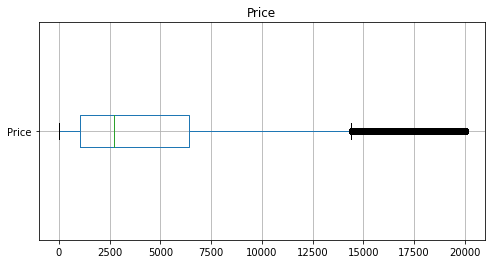

In [12]:
plt.figure(figsize=(8, 4))
df.boxplot(column='Price',vert=False)
plt.title('Price')
plt.show()


In [13]:
ROWS_COUNT = df.shape[0]

In [14]:
z = df[df['Price'] == 0].shape[0] / ROWS_COUNT * 100
f'{z:.2f}%'

'3.04%'

In [15]:
df = df.drop(df[df['Price'] == 0].index)

Удалены записи с нулевыми значениями признака.

### Марка авто

In [16]:
df['Brand'].isna().sum()

0

In [17]:
df['Brand'].unique()

array(['volkswagen', 'audi', 'jeep', 'skoda', 'bmw', 'peugeot', 'ford',
       'mazda', 'nissan', 'renault', 'mercedes_benz', 'opel', 'seat',
       'citroen', 'honda', 'fiat', 'mini', 'smart', 'hyundai',
       'sonstige_autos', 'alfa_romeo', 'subaru', 'volvo', 'mitsubishi',
       'kia', 'suzuki', 'lancia', 'toyota', 'chevrolet', 'dacia',
       'daihatsu', 'trabant', 'chrysler', 'jaguar', 'daewoo', 'porsche',
       'rover', 'saab', 'land_rover', 'lada'], dtype=object)

Дубликаты не найдены.

### Модель авто

In [18]:
z = df['Model'].isna().sum() / ROWS_COUNT * 100
f'{z:.2f}%'

'4.94%'

In [19]:
df['Model'] = df['Model'].fillna('unknown')

In [20]:
df.groupby('Brand')['Model'].agg(lambda x: ', '.join(sorted(x.unique())))

Brand
alfa_romeo               145, 147, 156, 159, other, spider, unknown
audi              100, 200, 80, 90, a1, a2, a3, a4, a5, a6, a8, ...
bmw               1er, 3er, 5er, 6er, 7er, i3, m_reihe, other, u...
chevrolet               aveo, captiva, matiz, other, spark, unknown
chrysler          300c, crossfire, grand, other, ptcruiser, unkn...
citroen                berlingo, c1, c2, c3, c4, c5, other, unknown
dacia                 duster, lodgy, logan, other, sandero, unknown
daewoo                  kalos, lanos, matiz, nubira, other, unknown
daihatsu          charade, cuore, materia, move, other, sirion, ...
fiat              500, bravo, croma, doblo, ducato, other, panda...
ford              b_max, c_max, escort, fiesta, focus, fusion, g...
honda                 accord, civic, cr_reihe, jazz, other, unknown
hyundai                getz, i_reihe, other, santa, tucson, unknown
jaguar                               other, s_type, unknown, x_type
jeep                      cherokee, grand,

Прямых дубликатов  нет, но есть семантические дубликаты и совпадения у разных марок в моделях.Совместим их во избежание ошибок у модели.

In [21]:
df['Model'] = df['Brand'] + '_' + df['Model']

### Год регистрации автомобиля

In [22]:
df['RegistrationYear'].describe().to_frame().T

,count,mean,std,min,25%,50%,75%,max
RegistrationYear,343593.0,2004.08983,78.41368,1000.0,1999.0,2003.0,2008.0,9999.0


Наблюдается большой разброс в значениях.

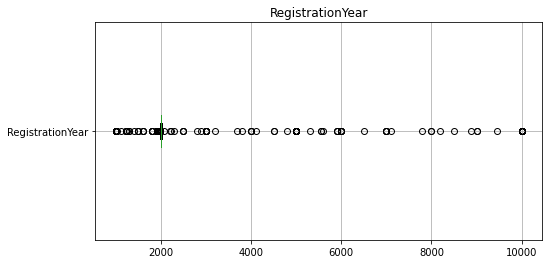

In [23]:
plt.figure(figsize=(8, 4))
df.boxplot(column='RegistrationYear',vert=False)
plt.title('RegistrationYear')
plt.show()


Сверим с годом выгрузки анкеты.

In [24]:
rows_idxs = df[df.apply(lambda x:x['RegistrationYear'] > x['DateCrawled'].year, axis=1)].index
f'{len(rows_idxs) / ROWS_COUNT * 100:.2f}%'

'3.89%'

In [25]:
df = df.drop(rows_idxs)

### Автомобильный кузов, коробка передач, тип топлива и  ремонт машины(или его отсутствие)

In [26]:
cols = ['VehicleType', 'Gearbox', 'FuelType', 'Repaired']
for column in cols:
    print(f'{column}: {df[column].isna().sum() / ROWS_COUNT * 100:.2f}%')



VehicleType: 5.64%
Gearbox: 4.42%
FuelType: 6.83%
Repaired: 16.91%


In [27]:
for column in cols:
    df[column] = df[column].fillna('unknown')

Заменены пропуски на неизвестные значения.

In [28]:
for column in cols:
    uniq_vals = ', '.join(sorted(df[column].unique()))
    print(f'{column}: {uniq_vals}')

VehicleType: bus, convertible, coupe, other, sedan, small, suv, unknown, wagon
Gearbox: auto, manual, unknown
FuelType: cng, electric, gasoline, hybrid, lpg, other, petrol, unknown
Repaired: no, unknown, yes


В FuelType присутствует семантический дубль: gasoline и petrol означают одно и то же, их следует объединить в одну категорию.

In [29]:
df['FuelType'] = df['FuelType'].replace({'gasoline': 'petrol'})

### Мощность

In [30]:
df['Kilometer'].describe().to_frame().T

,count,mean,std,min,25%,50%,75%,max
Kilometer,329814.0,128187.463237,37552.368252,5000.0,125000.0,150000.0,150000.0,150000.0


In [31]:
df['Kilometer'].isna().sum()

0

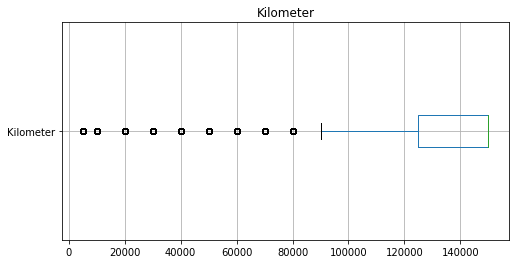

In [32]:
plt.figure(figsize=(8, 4))
df.boxplot(column='Kilometer',vert=False)
plt.title('Kilometer')
plt.show()

Вероятно этот признак является категориальным, ведь наблюдения находятся на одинаковом расстоянии друг от друга. 

In [33]:
df['Kilometer'].sort_values().unique()

array([  5000,  10000,  20000,  30000,  40000,  50000,  60000,  70000,
        80000,  90000, 100000, 125000, 150000])

Неинформативные признаки

NumberOfPictures — количество фотографий автомобиля(у всех записей отсутствуют фотографии).

RegistrationMonth — месяц регистрации автомобиля.

PostalCode — почтовый индекс владельца анкеты.

К неинформативным признакам можно отнести:

DateCrawled — дата скачивания анкеты из базы.

DateCreated — дата создания анкеты.

LastSeen — дата последней активности пользователя. 


In [34]:
useless_cols = ['DateCrawled', 'DateCreated', 'LastSeen', 
                   'NumberOfPictures', 'RegistrationMonth', 'PostalCode']
df = df.drop(useless_cols, axis=1)

In [35]:
df.duplicated().sum()

43107

После удаления неинформативных признаков появились полный дубликаты, оставим с возможной пользой для моделя knn.

## Исследовательский анализ

Количественные признаки

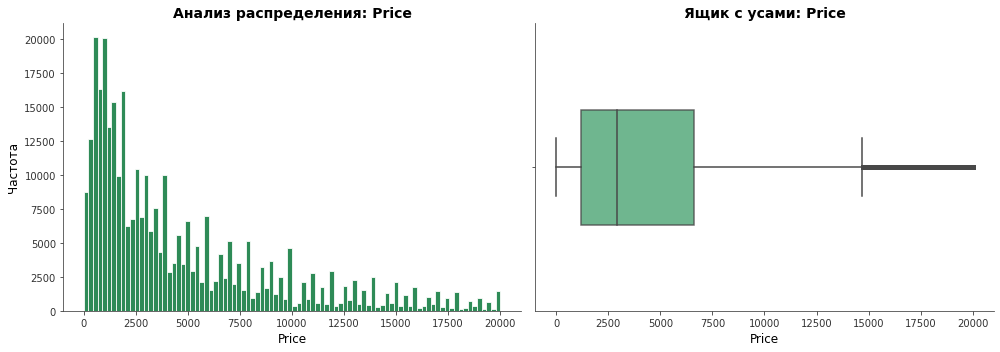

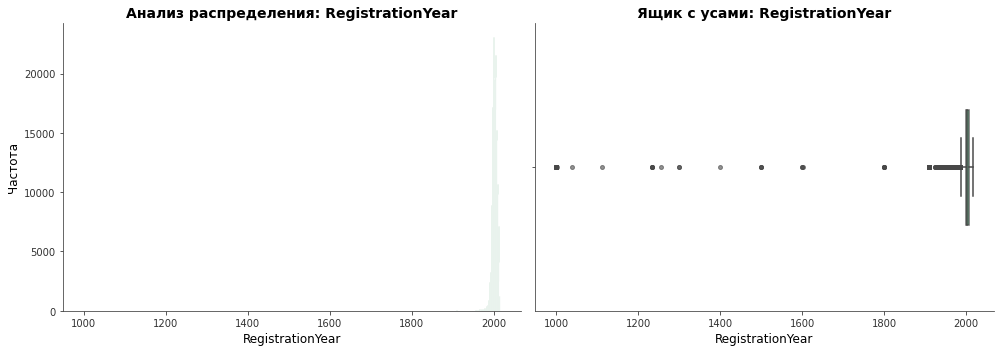

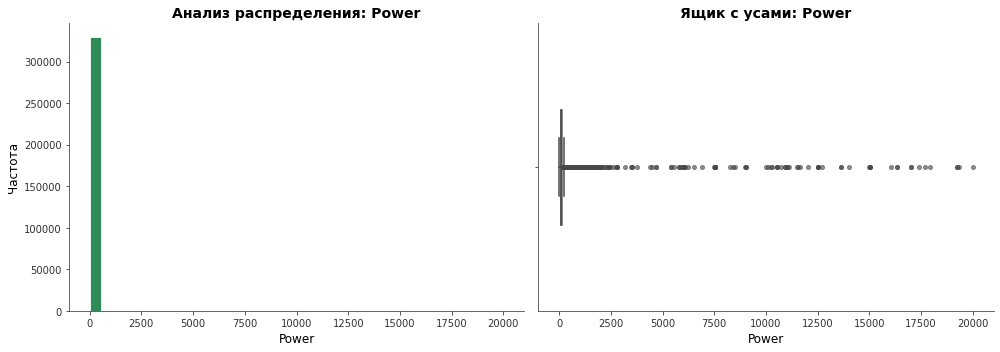

In [36]:
num_columns_bins = {
    'Price': 90,
    'RegistrationYear': df['RegistrationYear'].max() - df['RegistrationYear'].min() + 1,
    'Power': 35
}

for column, bins in num_columns_bins.items():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    sns.histplot(
        df[column], 
        ax=ax1, 
        bins=bins, 
        color='#2E8B57', 
        alpha=1, 
        edgecolor='#FFFFFF', 
        linewidth=0.8
    )
    ax1.set_title(f'Анализ распределения: {column}', fontsize=14, fontweight='bold')
    ax1.set_xlabel(column, fontsize=12)
    ax1.set_ylabel('Частота', fontsize=12)
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax1.spines['left'].set_color('#444444')
    ax1.spines['bottom'].set_color('#444444')
    ax1.tick_params(axis='x', colors='#333333')
    ax1.tick_params(axis='y', colors='#333333')

    sns.boxplot(
        x=df[column], 
        ax=ax2, 
        color='#3CB371', 
        width=0.4,
        boxprops=dict(alpha=0.8),
        flierprops=dict(marker='o', markersize=4, alpha=0.6)
    )
    ax2.set_title(f'Ящик с усами: {column}', fontsize=14, fontweight='bold')
    ax2.set_xlabel(column, fontsize=12)
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.spines['left'].set_color('#444444')
    ax2.spines['bottom'].set_color('#444444')
    ax2.tick_params(axis='x', colors='#333333')
    ax2.tick_params(axis='y', colors='#333333')

    plt.tight_layout()
    plt.show()


Категориальные признаки

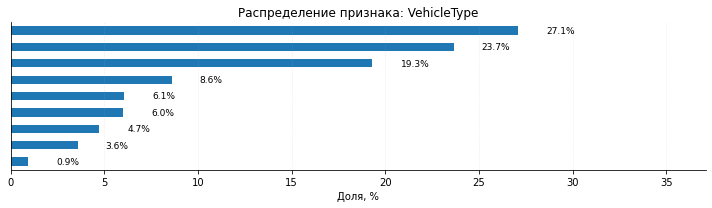

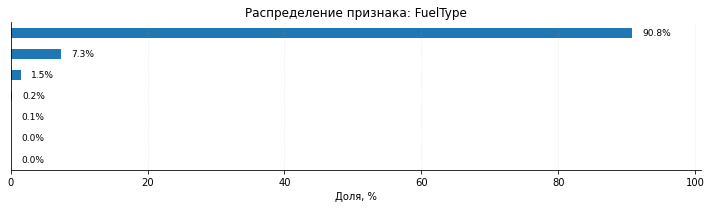

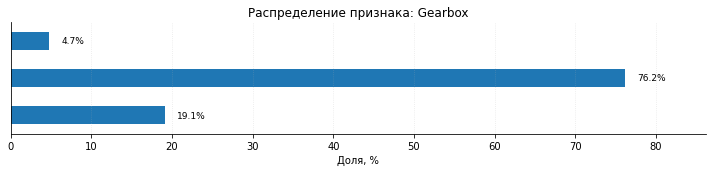

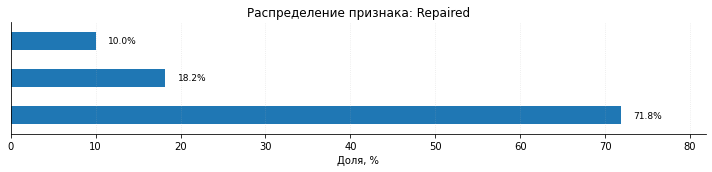

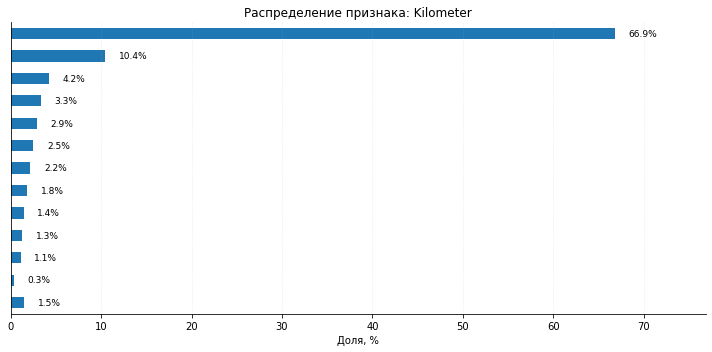

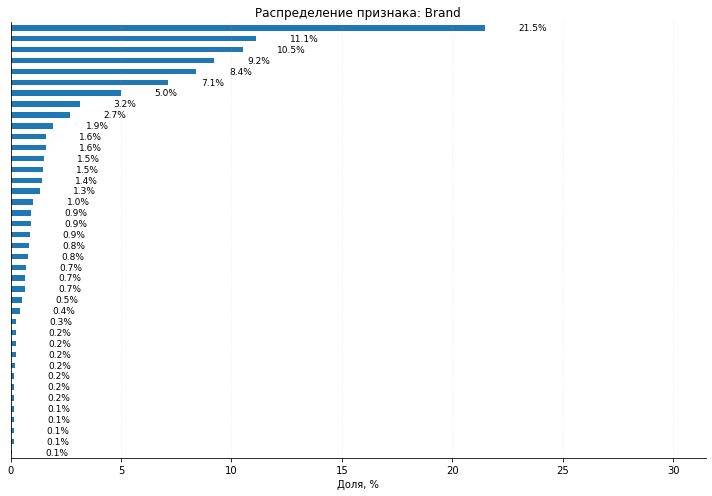

In [37]:
height_by_feature = {
    'VehicleType': 3,
    'FuelType': 3,
    'Gearbox': 2.5,
    'Repaired': 2.5,
    'Kilometer': 5,
    'Brand': 7
}

for feature_name, plot_height in height_by_feature.items():
    if feature_name not in df.columns:
        print(f"Столбец '{feature_name}' не найден в DataFrame.")
        continue

    if feature_name in ['Repaired', 'Gearbox']:
        df[feature_name] = df[feature_name].fillna('Unknown').astype(str)

    fig, ax = plt.subplots(figsize=(10, plot_height))
    distrib = df[feature_name].value_counts(normalize=True) * 100

    if feature_name == 'Kilometer':
        distrib = distrib.sort_index()
    elif feature_name in ['Repaired', 'Gearbox']:
        distrib = distrib.sort_index()
    else:
        distrib = distrib.sort_values()

    bars = distrib.plot(kind='barh', ax=ax)

    x_limit = distrib.max() + 10
    ax.set_xlim(0, x_limit)

    for bar in bars.patches:
        width = bar.get_width()
        ax.text(width + 1.5, bar.get_y() + bar.get_height() / 2,
                f'{width:.1f}%', va='center', fontsize=9)

    ax.set_title(f'Распределение признака: {feature_name}')
    ax.set_xlabel('Доля, %')
    ax.set_yticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='x', alpha=0.3, linestyle=':')
    plt.tight_layout()
    plt.show()


Матрица корреляций

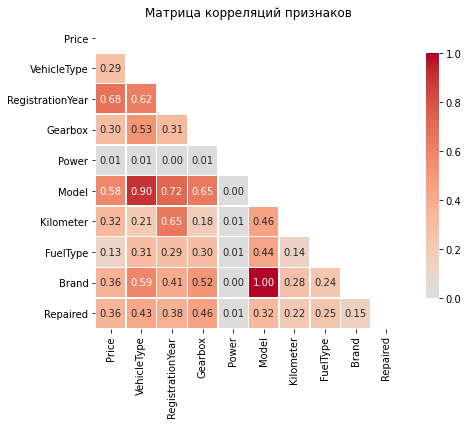

In [38]:
interval_columns = ['Price', 'Power']
corr_coefficients = df.phik_matrix(interval_cols=interval_columns)

mask = np.triu(np.ones_like(corr_coefficients, dtype=bool))

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_coefficients,
    mask=mask,
    cmap='coolwarm',
    center=0,
    annot=True,
    fmt='.2f',
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title('Матрица корреляций признаков')
plt.tight_layout()
plt.show()

Имеется мультиколлинеарность  между признаками Brand и Model.Так получилось в том числе из-за обьединения бренда и модели в модель.
Признаки RegistrationYear и Model имеют высокую корреляцию с целевым признаком Price.

По итогу исследовательского анализа:

есть выбросы в количественных признаках

у количественных признаков разные диапазоны значений, будем использовать масштабирование

дисбаланс классов в категориальных признаках

мультиколлинеарность марки и модели автомобиля





## Обучение моделей

In [39]:
class ModelsStat:
    def __init__(self, score_limit=2500):
        self.models = []
        self.score_limit = score_limit

    def add(self, name, params, fit_time, predict_time, score):
        self.models.append({
            'Модель': name,
            'Время обучения, сек': round(fit_time, 2),
            'Время предсказания, сек': round(predict_time, 2),
            'RMSE на кросс-валидации, евро': round(score, 2),
            'Параметры': params,
            'Модель подходит': score < self.score_limit
        })

    def to_frame(self):
        return pd.DataFrame(self.models) \
                 .sort_values(by=['Модель подходит', 'RMSE на кросс-валидации, евро'], 
                              ascending=[False, True]) \
                 .reset_index(drop=True)

In [40]:
RANDOM_STATE = 42
X_train, X_test, y_train, y_test = train_test_split(
    df.drop('Price', axis=1),
    df['Price'],
    test_size=0.25, 
    random_state=RANDOM_STATE
)



### Дамми-модель

In [41]:
dummy_model = DummyRegressor(strategy='mean')
dummy_model.fit(X_train, y_train)

mse = mean_squared_error(y_test, dummy_model.predict(X_test))
rmse_score = np.sqrt(mse)
f'RMSE: {rmse_score:.2f} евро'


'RMSE: 4548.48 евро'

### Линейная регрессия

In [42]:
def get_cv_results(gscv: GridSearchCV) -> list[float]:
    best_params = gscv.best_estimator_.named_steps['model'].get_params()
    display('Гиперпараметры лучшей модели: ' + str(best_params))
    
    fit_time = gscv.cv_results_['mean_fit_time'][gscv.best_index_]
    display(f'Время обучения: {fit_time:.2f} s')
    
    predict_time = gscv.cv_results_['mean_score_time'][gscv.best_index_]
    display(f'Время предсказания: {predict_time:.2f} s')
    
    score = -gscv.best_score_
    display(f'RMSE при кросс-валидации: {score:.2f} евро')

    return str(best_params), fit_time, predict_time, score

In [43]:
ohe_transformer = Pipeline(
    steps=[('imputer', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
           ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)
)]
)

num_transformer = Pipeline(
    steps=[('imputer', SimpleImputer(missing_values=np.nan, strategy='mean')),
           ('scaler', MinMaxScaler())]
)

data_preprocessor = ColumnTransformer(
    transformers=[('ohe', ohe_transformer, ['VehicleType', 'Gearbox', 'Model', 'FuelType', 'Repaired']),
                  ('num', num_transformer, ['RegistrationYear', 'Power', 'Kilometer'])], 
    remainder='drop', 
    verbose_feature_names_out=False
)


In [44]:
%%time

model_pipe = Pipeline(
    steps=[('preprocessor', data_preprocessor),
           ('model', LinearRegression())]
)

model_grid = [{
    'preprocessor__ohe__encoder__drop': ['first', None],
    'model__fit_intercept': [True, False]
}]

model_search_lr = GridSearchCV(model_pipe, model_grid, cv=3, n_jobs=-1, scoring='neg_root_mean_squared_error')
model_search_lr.fit(X_train, y_train)
pass



/opt/conda/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories

CPU times: user 2min 53s, sys: 1min 1s, total: 3min 54s
Wall time: 3min 55s


In [45]:
results = get_cv_results(model_search_lr)
models_stat = ModelsStat()
models_stat.add('LinearRegression', *results)

"Гиперпараметры лучшей модели: {'copy_X': True, 'fit_intercept': False, 'n_jobs': None, 'positive': False}"

'Время обучения: 17.00 s'

'Время предсказания: 0.77 s'

'RMSE при кросс-валидации: 3153.67 евро'

### Древо решений

In [46]:
ord_transformer = Pipeline(
    steps=[('imputer_before', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
           ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=np.nan)),
           ('imputer_after', SimpleImputer(missing_values=np.nan, strategy='most_frequent'))]
)

num_transformer = Pipeline(
    steps=[('imputer', SimpleImputer(missing_values=np.nan, strategy='mean')),
           ('scaler', MinMaxScaler())]
)

data_preprocessor = ColumnTransformer(
    transformers=[('ord', ord_transformer, ['VehicleType', 'Gearbox', 'Model', 'FuelType', 'Repaired']),
                  ('num', num_transformer, ['RegistrationYear', 'Power', 'Kilometer'])], 
    remainder='drop', 
    verbose_feature_names_out=False
)



In [47]:
%%time

model_pipe = Pipeline(
    steps=[('preprocessor', data_preprocessor),
           ('model', DecisionTreeRegressor(random_state=RANDOM_STATE))]
)

model_grid = [{
    'model__max_depth': [5, 10, 15]
}]

model_search_dtr = GridSearchCV(model_pipe, model_grid, cv=5, n_jobs=-1, scoring='neg_root_mean_squared_error')
model_search_dtr.fit(X_train, y_train)
pass



CPU times: user 15.6 s, sys: 0 ns, total: 15.6 s
Wall time: 15.7 s


In [48]:
results = get_cv_results(model_search_dtr)
models_stat.add('DecisionTreeRegressor', *results)

"Гиперпараметры лучшей модели: {'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': 15, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 42, 'splitter': 'best'}"

'Время обучения: 0.97 s'

'Время предсказания: 0.10 s'

'RMSE при кросс-валидации: 1940.94 евро'

### CatBoostRegressor

In [49]:
%%time

model_pipe = Pipeline(
    steps=[('model', CatBoostRegressor(cat_features=['VehicleType', 'Gearbox', 'Model', 'FuelType', 'Brand', 'Repaired'],
                                       iterations=20, loss_function='RMSE', verbose=False, 
                                       random_state=RANDOM_STATE))]
)

model_grid = [{
    'model__grow_policy': ['Depthwise', 'SymmetricTree']
}]

model_search_cbr = GridSearchCV(model_pipe, model_grid, cv=5, n_jobs=-1, scoring='neg_root_mean_squared_error')
model_search_cbr.fit(X_train, y_train)
pass



CPU times: user 26 s, sys: 0 ns, total: 26 s
Wall time: 43.1 s


In [50]:
results = get_cv_results(model_search_cbr)
models_stat.add('CatBoostRegressor', *results)

"Гиперпараметры лучшей модели: {'iterations': 20, 'loss_function': 'RMSE', 'verbose': False, 'random_state': 42, 'cat_features': ['VehicleType', 'Gearbox', 'Model', 'FuelType', 'Brand', 'Repaired'], 'grow_policy': 'Depthwise'}"

'Время обучения: 4.48 s'

'Время предсказания: 0.09 s'

'RMSE при кросс-валидации: 1805.47 евро'

### LGBMRegressor

In [51]:
%%time

X_train_lgbmr = X_train
for column in ['VehicleType', 'Gearbox', 'Model', 'FuelType', 'Brand', 'Repaired']:
    X_train_lgbmr[column] = X_train_lgbmr[column].astype('category')

model_pipe = Pipeline(
    steps=[('model', LGBMRegressor(metric='rmse', verbose=0, force_col_wise=True, random_state=RANDOM_STATE, max_bin=330))]
)

model_grid = [{
    'model__boosting_type': ['gbdt', 'dart']
}]

model_search_lgbmr = GridSearchCV(model_pipe, model_grid, cv=5, n_jobs=-1, scoring='neg_root_mean_squared_error')
model_search_lgbmr.fit(X_train_lgbmr, y_train)
pass

CPU times: user 2min 40s, sys: 0 ns, total: 2min 40s
Wall time: 2min 42s


In [52]:
results = get_cv_results(model_search_lgbmr)
models_stat.add('LGBMRegressor', *results)

"Гиперпараметры лучшей модели: {'boosting_type': 'gbdt', 'class_weight': None, 'colsample_bytree': 1.0, 'importance_type': 'split', 'learning_rate': 0.1, 'max_depth': -1, 'min_child_samples': 20, 'min_child_weight': 0.001, 'min_split_gain': 0.0, 'n_estimators': 100, 'n_jobs': -1, 'num_leaves': 31, 'objective': None, 'random_state': 42, 'reg_alpha': 0.0, 'reg_lambda': 0.0, 'silent': 'warn', 'subsample': 1.0, 'subsample_for_bin': 200000, 'subsample_freq': 0, 'metric': 'rmse', 'verbose': 0, 'force_col_wise': True, 'max_bin': 330}"

'Время обучения: 10.31 s'

'Время предсказания: 0.53 s'

'RMSE при кросс-валидации: 1659.09 евро'

## Анализ моделей

In [53]:
models_stat.to_frame()

,Модель,"Время обучения, сек","Время предсказания, сек","RMSE на кросс-валидации, евро",Параметры,Модель подходит
0,LGBMRegressor,10.31,0.53,1659.09,"{'boosting_type': 'gbdt', 'class_weight': None...",True
1,CatBoostRegressor,4.48,0.09,1805.47,"{'iterations': 20, 'loss_function': 'RMSE', 'v...",True
2,DecisionTreeRegressor,0.97,0.10,1940.94,"{'ccp_alpha': 0.0, 'criterion': 'squared_error...",True
3,LinearRegression,17.00,0.77,3153.67,"{'copy_X': True, 'fit_intercept': False, 'n_jo...",False


В ходе задачи были использованы 4 модели:

LinearRegression

DecisionTreeRegressor

CatBoostRegressor

LGBMRegressor


Линейная Регрессия не подойдет т.к. не преодолела порог на кросс-валидации в 2500.

Для заказчика важны 3 пункта: качество предсказания, время обучения модели и время предсказания модели. 

LGBMRegressor показывает лучшее качество (самый низкий RMSE — 1659.09), что важно для точности оценки рыночной стоимости.

Время обучения у LGBMRegressor умеренное (12.36 с), не слишком долгое для заказчика.

Время предсказания (0.56 с) приемлемое, не слишком большое.

Рекомендуется использовать LGBMRegressor как сбалансированный вариант с высоким качеством прогноза и приемлемым временем работы. Это оптимальный компромисс между скоростью и точностью, что соответствует ключевым требованиям заказчика.

### Распределение остатков 

In [61]:
X_test_lgbmr = X_test
for column in ['VehicleType', 'Gearbox', 'Model', 'FuelType', 'Brand', 'Repaired']:
    X_test_lgbmr[column] = X_test_lgbmr[column].astype('category')

predict = model_search_lgbmr.predict(X_test_lgbmr)
mse = mean_squared_error(y_test, predict)
rmse = np.sqrt(mse)
print(f'RMSE на тестовой выборке: {rmse:.2f} евро')



RMSE на тестовой выборке: 1634.24 евро


In [62]:
def display_residuals(y_true, y_pred, model_name, axes):
    residuals = y_true - y_pred
    

    axes[0].scatter(y_pred, residuals, alpha=0.3)
    axes[0].axhline(0, color='red', linestyle='--')
    axes[0].set_title(f'{model_name} Residuals vs Predictions')
    axes[0].set_xlabel('Predicted values')
    axes[0].set_ylabel('Residuals')


    axes[1].hist(residuals, bins=30, alpha=0.7)
    axes[1].set_title(f'{model_name} Residuals Distribution')
    axes[1].set_xlabel('Residual')
    axes[1].set_ylabel('Frequency')

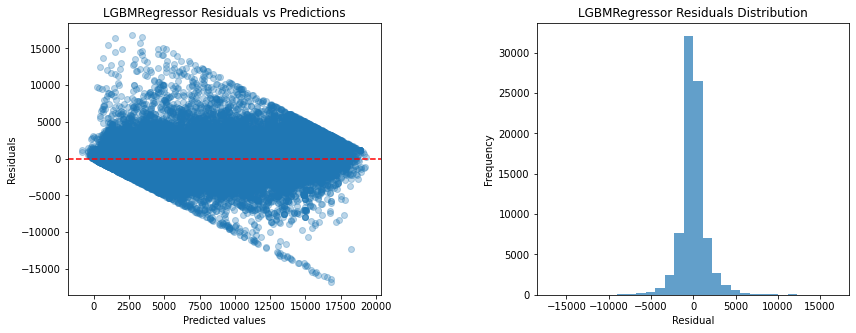

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.subplots_adjust(wspace=0.5)
display_residuals(y_test, predict, 'LGBMRegressor', axes)
plt.show()

Распределение остатков нормальное.

### Важность признаков

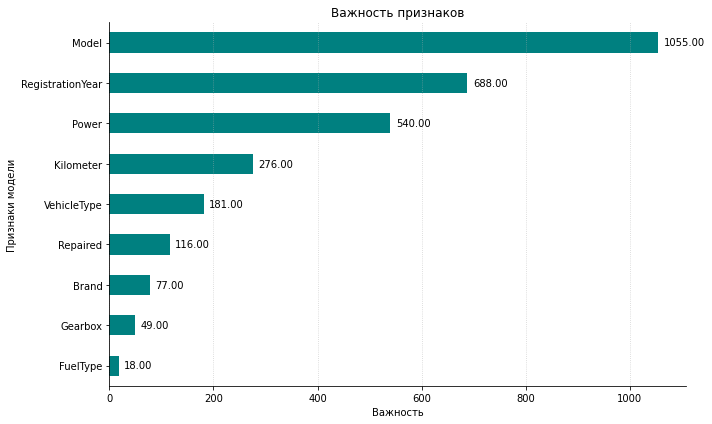

In [64]:
feature_importances = pd.Series(
    data=model_search_lgbmr.best_estimator_.named_steps['model'].feature_importances_,
    index=X_train_lgbmr.columns
).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))

feature_importances.plot(kind='barh', ax=ax, color='teal')

for i, v in enumerate(feature_importances):
    ax.text(v + feature_importances.max() * 0.01, i, f'{v:.2f}', va='center')

ax.set_title('Важность признаков')
ax.set_xlabel('Важность')
ax.set_ylabel('Признаки модели')
ax.grid(axis='x', linestyle=':', alpha=0.6)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


## Вывод

В ходе исследования была проведена комплексная работа по обработке и анализу данных о технических характеристиках, комплектации и ценах автомобилей с пробегом. Особое внимание уделялось качественной предобработке данных: пропуски были заполнены, выявлены и устранены аномалии, а также удалены неинформативные признаки, что позволило повысить надежность моделей.

Анализ данных выявил особенности распределения количественных и категориальных признаков, включая наличие выбросов и дисбаланса классов, а также мультиколлинеарность некоторых параметров, что было учтено в процессе построения моделей. Также была отмечена существенная корреляция цены с некоторыми характеристиками.

Путем обучения и сравнения нескольких моделей машинного обучения была выбрана оптимальная — LGBMRegressor. Она показала наилучшее качество предсказаний, удовлетворяя требованиям заказчика по метрике RMSE (меньше 2500 евро), а также демонстрирует приемлемое время обучения и быстроту предсказаний, что важно для использования в реальном приложении.

Выбранная модель предоставляет баланс между точностью и эффективностью, что делает её предпочтительным решением для прогноза рыночной стоимости автомобилей в сервисе.